## **Data Preprocessing**


<div style="text-align: justify; line-height: 1.65;">Notebook ini melanjutkan pembelajaran setelah Exploratory Data Analysis pada Day 1. Fokus utama sesi ini adalah menyiapkan data agar lebih bersih, konsisten, dan dapat digunakan oleh model machine learning. Setiap treatment dipilih berdasarkan karakteristik data, bukan karena seluruh teknik preprocessing harus selalu digunakan.</div>

<div style="text-align: justify; line-height: 1.65;">Prinsip yang digunakan sepanjang notebook adalah <b>fit pada training data, lalu transform validation dan test data</b>. Parameter seperti median, kategori encoder, mean, dan standard deviation tidak dipelajari dari validation maupun test data agar evaluasi model tetap mencerminkan data yang belum pernah digunakan untuk belajar.</div>

## **1. Instalasi dan Import Library**


In [1]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

<div style="text-align: justify; line-height: 1.65;">Library yang digunakan mencakup pengolahan data dengan pandas dan NumPy, visualisasi dengan Matplotlib dan Seaborn, serta beberapa utilitas preprocessing dari scikit learn. Teknik yang dibandingkan di notebook ini tetap dibatasi pada metode yang cukup mudah dipahami untuk level awal.</div>

## **2. Memuat Dataset**


In [3]:
DATA_URL = "https://raw.githubusercontent.com/clairedible/DataAnalyst_DSMBC/refs/heads/main/credit_risk_dataset.csv"

try:
    df = pd.read_csv(DATA_URL)
except Exception:
    df = pd.read_csv("credit_risk_dataset.csv")

print("Jumlah baris dan kolom:", df.shape)
display(df.head())

Jumlah baris dan kolom: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


<div style="text-align: justify; line-height: 1.65;">Dataset yang dimuat memiliki <b>32.581 observasi dan 12 kolom</b>. Lima baris pertama menunjukkan bahwa data terdiri dari kombinasi fitur numerik dan kategorikal, dengan <code>loan_status</code> sebagai target. Pada tampilan awal juga sudah terlihat nilai yang perlu diperiksa lebih lanjut, misalnya <code>person_emp_length = 123</code> pada peminjam berusia 22 tahun. Nilai seperti ini belum langsung dihapus karena validitasnya akan diperiksa pada tahap data cleaning.</div>


## **3. Ringkasan Masalah Data yang Akan Ditangani**


In [4]:
summary = pd.DataFrame({
    "jumlah_missing": df.isna().sum(),
    "tipe_data": df.dtypes.astype(str)
})

summary = summary[summary["jumlah_missing"] > 0]
print("Jumlah exact duplicate:", df.duplicated().sum())
display(summary)

Jumlah exact duplicate: 165


,jumlah_missing,tipe_data
person_emp_length,895,float64
loan_int_rate,3116,float64


<div style="text-align: justify; line-height: 1.65;">Pemeriksaan awal menemukan <b>165 exact duplicate</b>. Missing value hanya muncul pada <code>loan_int_rate</code> sebanyak <b>3.116 observasi</b> atau sekitar <b>9,56 persen</b> dan <code>person_emp_length</code> sebanyak <b>895 observasi</b> atau sekitar <b>2,75 persen</b>. Temuan ini menunjukkan bahwa missing value tidak tersebar pada seluruh fitur sehingga treatment dapat difokuskan pada kolom yang memang membutuhkan penanganan.</div>


## **4. Data Cleaning**


<div style="text-align: justify; line-height: 1.65;">Data cleaning digunakan untuk menangani masalah yang sudah dapat dinilai sebagai masalah kualitas data. Nilai yang hanya terlihat ekstrem secara statistik tidak langsung dihapus pada tahap ini karena masih perlu diperiksa konteksnya.</div>

## **4.1 Exact Duplicate**


In [5]:
df_prep = df.copy()

print("Duplicate sebelum cleaning:", df_prep.duplicated().sum())
df_prep = df_prep.drop_duplicates().reset_index(drop=True)
print("Duplicate setelah cleaning:", df_prep.duplicated().sum())
print("Jumlah baris setelah cleaning:", len(df_prep))

Duplicate sebelum cleaning: 165
Duplicate setelah cleaning: 0
Jumlah baris setelah cleaning: 32416


<div style="text-align: justify; line-height: 1.65;">Sebanyak <b>165 baris duplikat</b> berhasil dihapus sehingga jumlah observasi berkurang dari 32.581 menjadi <b>32.416</b>. Setelah proses ini jumlah exact duplicate menjadi <b>0</b>. Penghapusan dilakukan sebelum pembagian data agar record yang identik tidak berpotensi tersebar ke training, validation, dan test data.</div>


## **4.2 Validasi Nilai Berdasarkan Domain**


<div style="text-align: justify; line-height: 1.65;">Nilai yang terlihat tidak wajar perlu dibedakan dari nilai yang hanya jarang terjadi. Pada dataset ini, usia 123 tahun atau lebih ditandai sebagai nilai yang tidak valid untuk latihan ini. Selain itu, lama bekerja yang lebih besar daripada usia juga melanggar hubungan logis antarfitur. Pada project nyata, batas semacam ini sebaiknya berasal dari dokumentasi sumber data, aturan bisnis, atau ahli domain.</div>

In [6]:
invalid_age = df_prep["person_age"] >= 123
invalid_emp = (
    df_prep["person_emp_length"].notna()
    & (df_prep["person_emp_length"] > df_prep["person_age"])
)

print("Usia 123 tahun atau lebih:", invalid_age.sum())
print("Employment length lebih besar dari age:", invalid_emp.sum())

display(
    df_prep.loc[
        invalid_age | invalid_emp,
        ["person_age", "person_emp_length", "person_income", "loan_status"]
    ]
)

Usia 123 tahun atau lebih: 5
Employment length lebih besar dari age: 2


,person_age,person_emp_length,person_income,loan_status
0,22,123.0,59000,1
81,144,4.0,250000,0
183,144,4.0,200000,0
210,21,123.0,192000,0
575,123,2.0,80004,0
747,123,7.0,78000,0
32132,144,12.0,6000000,0


<div style="text-align: justify; line-height: 1.65;">Pemeriksaan berbasis domain menemukan <b>5 observasi dengan usia 123 tahun atau lebih</b> dan <b>2 observasi dengan lama bekerja lebih besar daripada usia</b>. Tabel memperlihatkan dua kasus lama bekerja 123 tahun pada usia 22 dan 21 tahun, serta beberapa usia 123 dan 144 tahun. Kasus tersebut memiliki dasar logis yang cukup kuat untuk ditandai sebagai nilai tidak valid, berbeda dengan nilai yang hanya ekstrem secara statistik.</div>


In [7]:
df_prep.loc[df_prep["person_age"] >= 123, "person_age"] = np.nan

invalid_emp = (
    df_prep["person_emp_length"].notna()
    & df_prep["person_age"].notna()
    & (df_prep["person_emp_length"] > df_prep["person_age"])
)

df_prep.loc[invalid_emp, "person_emp_length"] = np.nan

missing_after_domain = df_prep.isna().sum().sort_values(ascending=False)
display(missing_after_domain[missing_after_domain > 0].to_frame("missing"))

,missing
loan_int_rate,3095
person_emp_length,889
person_age,5


<div style="text-align: justify; line-height: 1.65;">Nilai yang tidak valid diubah menjadi missing value agar informasi pada kolom lain dalam baris yang sama tetap dapat dipertahankan. Setelah duplicate dihapus dan validasi domain dilakukan, terdapat <b>3.095 missing value pada loan_int_rate</b>, <b>889 pada person_emp_length</b>, dan <b>5 pada person_age</b>. Jumlah pada dua fitur pertama sedikit lebih rendah dibanding pemeriksaan awal karena sebagian record yang memiliki missing value termasuk dalam baris duplikat yang sudah dihapus.</div>


## **5. Feature dan Target Separation**


In [8]:
TARGET = "loan_status"
X = df_prep.drop(columns=[TARGET])
y = df_prep[TARGET]

print("Shape feature:", X.shape)
print("Shape target:", y.shape)
print("Proporsi target:")
display((y.value_counts(normalize=True) * 100).round(2).to_frame("persen"))

Shape feature: (32416, 11)
Shape target: (32416,)
Proporsi target:


,persen
loan_status,
0,78.13
1,21.87


<div style="text-align: justify; line-height: 1.65;">Target dipisahkan dari feature sebelum preprocessing lebih lanjut. <code>loan_status</code> tetap disimpan secara terpisah sehingga transformasi seperti imputation, encoding, dan scaling hanya diterapkan pada feature.</div>

## **6. Train, Validation, dan Test Split**


<div style="text-align: justify; line-height: 1.65;">Dataset dibagi menjadi 70 persen training data, 15 persen validation data, dan 15 persen test data. Stratification digunakan karena target memiliki proporsi kelas yang tidak sama, sehingga komposisi kelas tetap relatif konsisten pada setiap subset.</div>

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

for name, target in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(name, target.value_counts(normalize=True).round(3).to_dict())

Train: (22691, 11) (22691,)
Validation: (4862, 11) (4862,)
Test: (4863, 11) (4863,)
Train {0: 0.781, 1: 0.219}
Validation {0: 0.781, 1: 0.219}
Test {0: 0.781, 1: 0.219}


<div style="text-align: justify; line-height: 1.65;">Hasil pembagian menghasilkan <b>22.691 observasi training</b>, <b>4.862 validation</b>, dan <b>4.863 test</b>. Ketiganya tetap mempertahankan komposisi target sekitar <b>78,1 persen kelas 0</b> dan <b>21,9 persen kelas 1</b>. Total observasi dari ketiga subset tetap sama dengan 32.416, sehingga tidak ada data yang hilang selama proses split.</div>


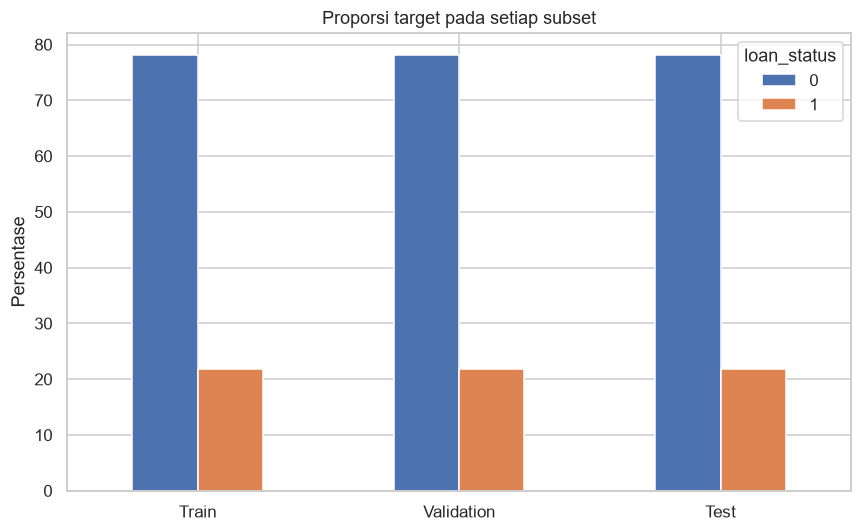

In [10]:
split_target = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).T * 100

split_target.plot(kind="bar", figsize=(8, 5))
plt.title("Proporsi target pada setiap subset")
plt.ylabel("Persentase")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="loan_status")
plt.tight_layout()
plt.show()

<div style="text-align: justify; line-height: 1.65;">Visualisasi memperlihatkan tinggi batang kelas 0 dan kelas 1 yang hampir sama pada training, validation, dan test data. Pola ini mengonfirmasi bahwa stratification berhasil menjaga proporsi target antar subset. Dengan distribusi yang konsisten, perbandingan performa model pada tahap berikutnya tidak terganggu oleh perubahan komposisi kelas akibat proses pembagian data.</div>


<div style="text-align: justify; line-height: 1.65;">Mulai titik ini, parameter preprocessing hanya dipelajari dari training data. Validation dan test data menerima transformasi yang sama tanpa ikut menentukan median, frekuensi kategori, maupun parameter scaling.</div>

In [11]:
X_train_prep = X_train.copy()
X_val_prep = X_val.copy()
X_test_prep = X_test.copy()

## **7. Missing Value Handling**


<div style="text-align: justify; line-height: 1.65;">Missing value dapat ditangani dengan beberapa pendekatan sederhana seperti menghapus observasi, menggunakan mean, median, atau mode. Pemilihan metode perlu mempertimbangkan jumlah data yang hilang, tipe fitur, dan bentuk distribusinya.</div>

In [12]:
missing_train = X_train_prep.isna().sum()
missing_train = missing_train[missing_train > 0]

missing_table = pd.DataFrame({
    "jumlah_missing": missing_train,
    "persen_train": (missing_train / len(X_train_prep) * 100).round(2)
})

display(missing_table)

,jumlah_missing,persen_train
person_age,3,0.01
person_emp_length,625,2.75
loan_int_rate,2179,9.60


<div style="text-align: justify; line-height: 1.65;">Pada training data, missing value paling banyak terdapat pada <code>loan_int_rate</code> sebanyak <b>2.179 observasi atau 9,60 persen</b>. <code>person_emp_length</code> memiliki <b>625 missing value atau 2,75 persen</b>, sedangkan <code>person_age</code> hanya memiliki <b>3 missing value atau 0,01 persen</b>. Proporsi ini menunjukkan bahwa penghapusan seluruh baris, terutama untuk <code>loan_int_rate</code>, akan membuang cukup banyak data sehingga imputation lebih layak dipertimbangkan.</div>


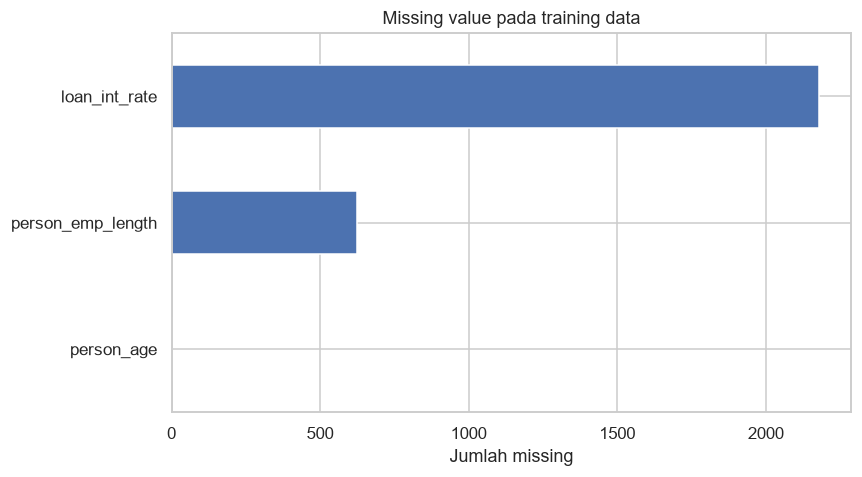

In [13]:
missing_table.sort_values("jumlah_missing").plot(
    kind="barh",
    y="jumlah_missing",
    legend=False,
    figsize=(8, 4.5)
)
plt.title("Missing value pada training data")
plt.xlabel("Jumlah missing")
plt.ylabel("")
plt.tight_layout()
plt.show()

<div style="text-align: justify; line-height: 1.65;">Grafik menunjukkan bahwa missing value pada <code>loan_int_rate</code> jauh lebih dominan dibanding dua fitur lainnya. <code>person_age</code> hampir tidak terlihat karena hanya memiliki tiga missing value. Perbedaan ini membantu melihat bahwa tingkat masalah missing value tidak sama pada setiap fitur, meskipun ketiganya tetap dapat ditangani melalui strategi imputation yang konsisten.</div>


## **7.1 Perbandingan Metode Imputation**


In [14]:
missing_cols = X_train_prep.columns[X_train_prep.isna().any()].tolist()

comparison = []
for col in missing_cols:
    comparison.append({
        "feature": col,
        "missing": X_train_prep[col].isna().sum(),
        "mean": X_train_prep[col].mean(),
        "median": X_train_prep[col].median(),
        "rows_lost_if_drop": X_train_prep[col].isna().sum()
    })

display(pd.DataFrame(comparison).round(3))

,feature,missing,mean,median,rows_lost_if_drop
0,person_age,3,27.722,26.00,3
1,person_emp_length,625,4.767,4.00,625
2,loan_int_rate,2179,11.021,10.99,2179


<div style="text-align: justify; line-height: 1.65;">Nilai mean dan median pada <code>loan_int_rate</code> hampir sama, yaitu sekitar <b>11,021</b> dan <b>10,99</b>. Perbedaannya lebih terlihat pada <code>person_age</code>, yaitu 27,722 dibanding 26, serta <code>person_emp_length</code>, yaitu 4,767 dibanding 4. Median lebih tahan terhadap nilai ekstrem dan distribusi yang tidak simetris, sehingga dipilih sebagai baseline imputation. Jika baris langsung dihapus, kehilangan data terbesar akan berasal dari <code>loan_int_rate</code> dengan 2.179 observasi pada training data.</div>


## **7.2 Median Imputation**


In [15]:
missing_numeric_cols = [
    col for col in X_train_prep.columns
    if X_train_prep[col].isna().any()
    and pd.api.types.is_numeric_dtype(X_train_prep[col])
]

median_imputer = SimpleImputer(strategy="median")

X_train_prep[missing_numeric_cols] = median_imputer.fit_transform(
    X_train_prep[missing_numeric_cols]
)
X_val_prep[missing_numeric_cols] = median_imputer.transform(
    X_val_prep[missing_numeric_cols]
)
X_test_prep[missing_numeric_cols] = median_imputer.transform(
    X_test_prep[missing_numeric_cols]
)

print("Kolom yang diimputasi:", missing_numeric_cols)
print("Missing train:", X_train_prep[missing_numeric_cols].isna().sum().sum())
print("Missing validation:", X_val_prep[missing_numeric_cols].isna().sum().sum())
print("Missing test:", X_test_prep[missing_numeric_cols].isna().sum().sum())

Kolom yang diimputasi: ['person_age', 'person_emp_length', 'loan_int_rate']
Missing train: 0
Missing validation: 0
Missing test: 0


<div style="text-align: justify; line-height: 1.65;">Median imputation berhasil menghilangkan seluruh missing value pada training, validation, dan test data. Nilai median hanya dipelajari dari training data melalui proses <code>fit</code>, kemudian digunakan untuk mentransformasi validation dan test data. Hasil <b>0 missing value</b> pada ketiga subset menunjukkan bahwa treatment sudah konsisten tanpa menggunakan informasi dari validation atau test untuk menentukan nilai imputasi.</div>


## **8. Outlier Detection dan Domain Validation**


<div style="text-align: justify; line-height: 1.65;">Outlier secara statistik belum tentu merupakan data yang salah. Deteksi statistik digunakan untuk menemukan kandidat yang perlu diperiksa, sedangkan keputusan akhirnya tetap mempertimbangkan konteks dan kewajaran nilai pada domain kredit.</div>

## **8.1 IQR dan Z Score sebagai Deteksi Awal**


In [16]:
numeric_cols = X_train_prep.select_dtypes(include=np.number).columns.tolist()

def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

outlier_summary = []
for col in numeric_cols:
    iqr_count, lower, upper = iqr_outlier_count(X_train_prep[col])
    z_count = (np.abs(zscore(X_train_prep[col])) > 3).sum()
    outlier_summary.append({
        "feature": col,
        "IQR_outliers": int(iqr_count),
        "Zscore_outliers": int(z_count),
        "IQR_lower": lower,
        "IQR_upper": upper
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary.round(3))

,feature,IQR_outliers,Zscore_outliers,IQR_lower,IQR_upper
0,person_age,1040,387,12.50,40.50
1,person_income,1139,151,-22500.00,139900.00
2,person_emp_length,578,297,-5.50,14.50
3,loan_amnt,1139,222,-6137.50,23562.50
4,loan_int_rate,46,37,1.56,20.04
5,loan_percent_income,455,232,-0.12,0.44
6,cb_person_cred_hist_length,800,204,-4.50,15.50


<div style="text-align: justify; line-height: 1.65;">IQR dan Z Score menghasilkan jumlah kandidat outlier yang berbeda pada seluruh fitur numerik. Contohnya, <code>person_income</code> ditandai sebanyak <b>1.139 observasi oleh IQR</b> tetapi hanya <b>151 oleh Z Score</b>, sedangkan <code>person_age</code> menghasilkan 1.040 kandidat dengan IQR dan 387 dengan Z Score. Batas IQR juga dapat menghasilkan batas bawah yang secara domain tidak mungkin, seperti pendapatan minus 22.500. Hal ini menunjukkan bahwa batas statistik berfungsi sebagai alat deteksi, bukan sebagai aturan domain untuk menentukan apakah sebuah nilai benar atau salah.</div>


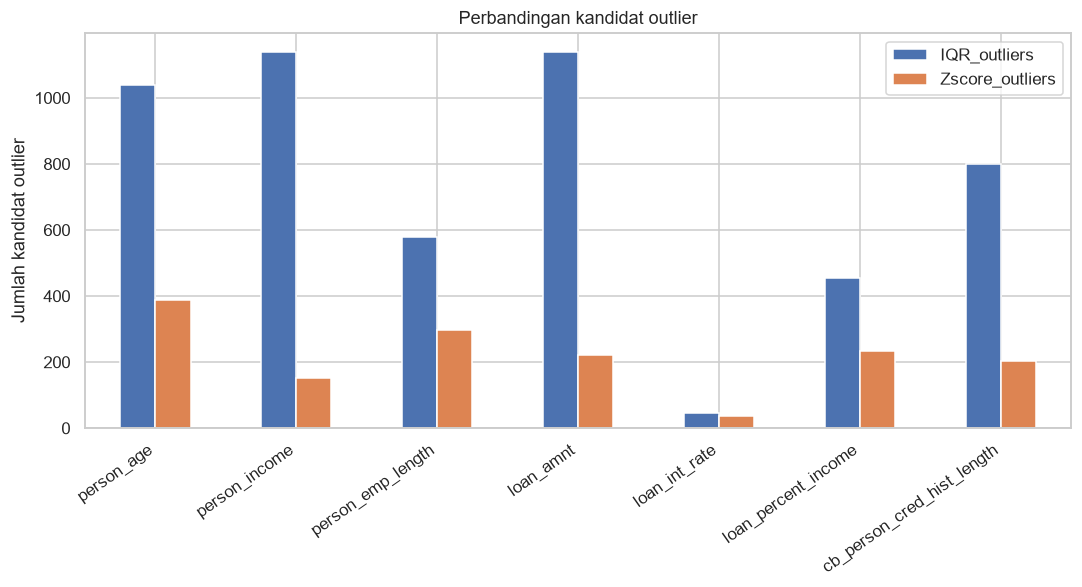

In [17]:
outlier_summary.set_index("feature")[["IQR_outliers", "Zscore_outliers"]].plot(
    kind="bar",
    figsize=(10, 5.5)
)
plt.title("Perbandingan kandidat outlier")
plt.ylabel("Jumlah kandidat outlier")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

<div style="text-align: justify; line-height: 1.65;">Grafik memperlihatkan bahwa IQR secara umum menandai lebih banyak kandidat outlier dibanding Z Score. Perbedaan paling jelas terlihat pada <code>person_income</code>, <code>loan_amnt</code>, <code>person_age</code>, dan riwayat kredit. Pola ini menegaskan bahwa jumlah outlier sangat bergantung pada metode yang digunakan, sehingga keputusan treatment tidak tepat jika hanya didasarkan pada satu threshold statistik.</div>


## **8.2 Pemeriksaan Kandidat Berdasarkan Domain**


In [18]:
for col in ["person_age", "person_income", "person_emp_length", "loan_amnt"]:
    print("Nilai terbesar untuk", col)
    display(
        X_train_prep.nlargest(5, col)[
            ["person_age", "person_income", "person_emp_length",
             "loan_amnt", "loan_int_rate", "loan_percent_income"]
        ]
    )

Nilai terbesar untuk person_age


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
32251,94.0,24000,1.0,6500,10.99,0.27
32369,76.0,75000,23.0,15000,8.94,0.20
32216,73.0,42000,7.0,5000,7.49,0.12
32356,73.0,39240,0.0,1800,12.53,0.05
32218,70.0,30000,1.0,5000,10.96,0.17


Nilai terbesar untuk person_income


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
32132,26.0,6000000,12.0,5000,12.73,0.00
29890,42.0,2039784,0.0,8450,12.29,0.00
32332,63.0,1782000,13.0,12025,14.27,0.01
31765,44.0,1440000,7.0,6400,7.40,0.00
31763,47.0,1362000,9.0,6600,7.74,0.00


Nilai terbesar untuk person_emp_length


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
32350,53.0,106000,38.0,20000,9.88,0.19
32263,58.0,49000,34.0,7500,13.55,0.15
31708,46.0,180000,31.0,18000,9.91,0.10
30755,48.0,70000,31.0,9000,14.54,0.13
31707,47.0,178000,31.0,9000,10.99,0.05


Nilai terbesar untuk loan_amnt


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
25582,27.0,78000,2.0,35000,17.27,0.45
15300,25.0,130000,9.0,35000,10.99,0.27
31543,42.0,125000,5.0,35000,7.90,0.28
28970,40.0,540600,8.0,35000,15.99,0.06
26984,27.0,122880,3.0,35000,8.49,0.28


<div style="text-align: justify; line-height: 1.65;">Setelah nilai yang jelas tidak valid dibersihkan, usia tertinggi pada training data adalah <b>94 tahun</b> dan lama bekerja tertinggi adalah <b>38 tahun</b>. Nilai tersebut berada jauh dari mayoritas data tetapi masih memiliki hubungan yang masuk akal dengan fitur lain. Pendapatan mencapai <b>6.000.000</b> dan jumlah pinjaman mencapai <b>35.000</b>; keduanya ekstrem, tetapi output tidak memberikan bukti bahwa nilainya merupakan kesalahan pencatatan. Karena itu, nilai ekstrem yang masih masuk akal dipertahankan.</div>


## **8.3 Capping sebagai Alternatif**


In [19]:
income_demo = X_train_prep["person_income"].copy()
lower_cap = income_demo.quantile(0.01)
upper_cap = income_demo.quantile(0.99)
income_capped_demo = income_demo.clip(lower=lower_cap, upper=upper_cap)

print("Minimum sebelum capping:", income_demo.min())
print("Maksimum sebelum capping:", income_demo.max())
print("Minimum setelah capping:", income_capped_demo.min())
print("Maksimum setelah capping:", income_capped_demo.max())

Minimum sebelum capping: 4000
Maksimum sebelum capping: 6000000
Minimum setelah capping: 14400
Maksimum setelah capping: 225000


<div style="text-align: justify; line-height: 1.65;">Simulasi capping pada persentil 1 dan 99 mengubah rentang <code>person_income</code> dari <b>4.000 sampai 6.000.000</b> menjadi <b>14.400 sampai 225.000</b>. Perubahan ini menunjukkan bahwa capping dapat mengurangi pengaruh ekor distribusi secara kuat tanpa menghapus observasi. Namun, informasi nilai pendapatan yang sangat rendah maupun sangat tinggi juga ikut dibatasi, sehingga teknik ini hanya ditampilkan sebagai alternatif dan tidak digunakan sebagai treatment final.</div>


## **9. Skewness Handling**


In [20]:
skew_before = X_train_prep[numeric_cols].skew().sort_values(ascending=False)
display(skew_before.to_frame("skewness_before").round(3))

,skewness_before
person_income,39.291
person_age,1.936
cb_person_cred_hist_length,1.673
person_emp_length,1.247
loan_amnt,1.171
loan_percent_income,1.051
loan_int_rate,0.214


<div style="text-align: justify; line-height: 1.65;"><code>person_income</code> memiliki skewness paling tinggi, yaitu <b>39,291</b>, sehingga distribusinya sangat menceng ke kanan. Fitur lain juga menunjukkan positive skew dengan tingkat yang lebih rendah, seperti <code>person_age</code> 1,936, riwayat kredit 1,673, dan <code>person_emp_length</code> 1,247. <code>loan_int_rate</code> memiliki skewness 0,214 sehingga bentuk distribusinya relatif lebih seimbang. Perbedaan ini menunjukkan bahwa transformasi tidak perlu diterapkan dengan cara yang sama pada seluruh fitur.</div>


## **9.1 Log dan Square Root Transformation**


,representation,skewness
0,Original,39.291
1,Log1p,0.158
2,Square Root,2.980


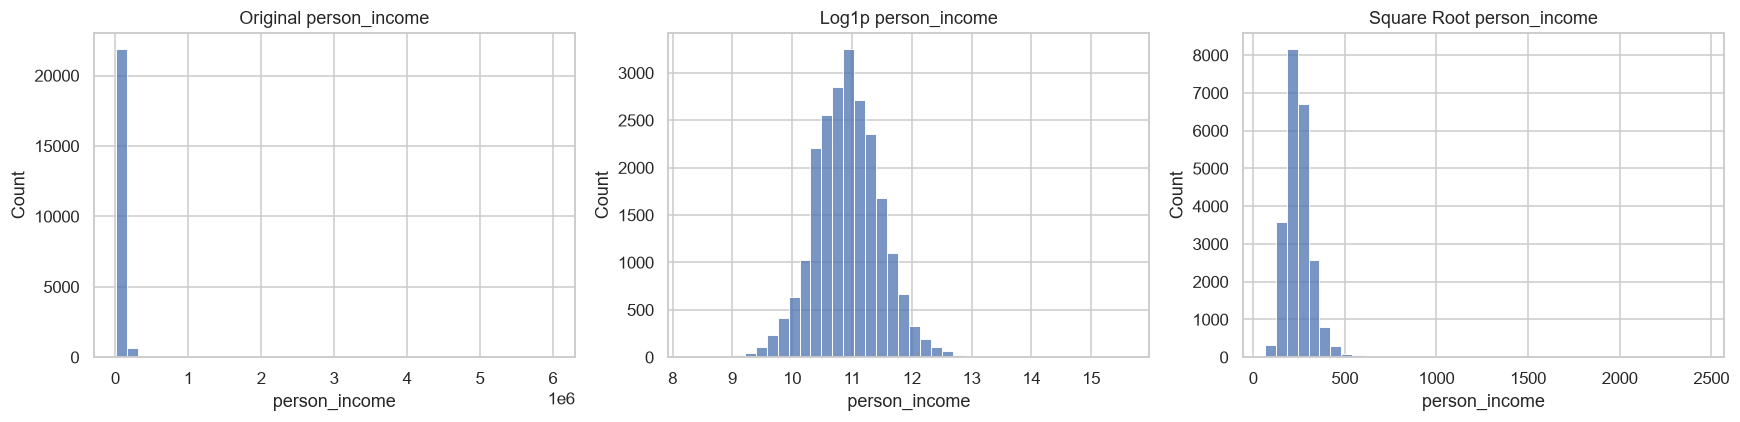

In [21]:
income_original = X_train_prep["person_income"]
income_log = np.log1p(income_original)
income_sqrt = np.sqrt(income_original)

skew_compare = pd.DataFrame({
    "representation": ["Original", "Log1p", "Square Root"],
    "skewness": [
        income_original.skew(),
        income_log.skew(),
        income_sqrt.skew()
    ]
})

display(skew_compare.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(income_original, bins=40, ax=axes[0])
axes[0].set_title("Original person_income")

sns.histplot(income_log, bins=40, ax=axes[1])
axes[1].set_title("Log1p person_income")

sns.histplot(income_sqrt, bins=40, ax=axes[2])
axes[2].set_title("Square Root person_income")

plt.tight_layout()
plt.show()

<div style="text-align: justify; line-height: 1.65;">Perbandingan menunjukkan bahwa log transformation paling efektif untuk <code>person_income</code>. Skewness turun dari <b>39,291</b> pada data asli menjadi <b>0,158</b> setelah <code>log1p</code>, sementara square root transformation masih menghasilkan skewness <b>2,980</b>. Histogram juga menunjukkan distribusi hasil log menjadi jauh lebih seimbang, sehingga log transformation dipilih untuk fitur ini.</div>


In [22]:
for split_df in [X_train_prep, X_val_prep, X_test_prep]:
    split_df["person_income"] = np.log1p(split_df["person_income"])

print(
    "Skewness person_income setelah log transform pada train:",
    round(X_train_prep["person_income"].skew(), 3)
)

Skewness person_income setelah log transform pada train: 0.158


<div style="text-align: justify; line-height: 1.65;">Setelah log transformation diterapkan pada seluruh subset, skewness <code>person_income</code> pada training data menjadi <b>0,158</b>. Nilai tersebut jauh lebih dekat ke distribusi simetris dibanding kondisi awal. Transformasi log bersifat deterministik sehingga rumus yang sama dapat langsung diterapkan secara konsisten pada training, validation, dan test data.</div>


## **10. Feature Engineering**


<div style="text-align: justify; line-height: 1.65;">Feature engineering bertujuan membentuk representasi yang lebih informatif dari feature yang sudah tersedia. Penambahan feature tetap perlu memiliki alasan yang jelas agar tidak sekadar menambah dimensi data.</div>

## **10.1 Ratio Feature**


In [23]:
ratio_demo = X_train["loan_amnt"] / X_train["person_income"]

demo_ratio = pd.DataFrame({
    "loan_amnt": X_train["loan_amnt"].head(),
    "person_income": X_train["person_income"].head(),
    "calculated_ratio": ratio_demo.head(),
    "existing_loan_percent_income": X_train["loan_percent_income"].head()
})

display(demo_ratio.round(4))

,loan_amnt,person_income,calculated_ratio,existing_loan_percent_income
7126,4000,51684,0.0774,0.08
15645,15000,90000,0.1667,0.17
7626,6400,93500,0.0684,0.07
20390,4800,49200,0.0976,0.10
7969,5000,49000,0.1020,0.10


<div style="text-align: justify; line-height: 1.65;">Nilai <code>calculated_ratio</code> hampir sama dengan <code>loan_percent_income</code> yang sudah tersedia. Sebagai contoh, rasio 0,0774 tercatat sebagai 0,08 dan rasio 0,1667 tercatat sebagai 0,17 setelah pembulatan. Artinya, membuat fitur rasio baru dari <code>loan_amnt</code> dan <code>person_income</code> akan membawa informasi yang pada dasarnya sudah terdapat dalam dataset dan berpotensi menambah redundansi.</div>


## **10.2 Binning sebagai Alternatif Representasi**


In [24]:
age_bin_demo = pd.cut(
    X_train_prep["person_age"],
    bins=[0, 25, 35, 50, np.inf],
    labels=["25 atau kurang", "26 sampai 35", "36 sampai 50", "lebih dari 50"]
)

display(age_bin_demo.value_counts().sort_index().to_frame("count"))

,count
person_age,
25 atau kurang,10679
26 sampai 35,9620
36 sampai 50,2189
lebih dari 50,203


<div style="text-align: justify; line-height: 1.65;">Hasil binning menunjukkan bahwa training data didominasi kelompok usia muda. Terdapat <b>10.679 observasi berusia 25 tahun atau kurang</b> dan <b>9.620 observasi berusia 26 sampai 35 tahun</b>. Kelompok 36 sampai 50 tahun berjumlah 2.189 observasi dan usia di atas 50 tahun hanya 203 observasi. Binning membuat distribusi umur lebih mudah diringkas, tetapi mengurangi detail nilai kontinu sehingga pada notebook ini hanya digunakan sebagai contoh alternatif representasi.</div>


## **11. Categorical Encoding**


<div style="text-align: justify; line-height: 1.65;">Fitur kategorikal perlu direpresentasikan secara numerik sebelum digunakan oleh banyak algoritma machine learning. Metode encoding dipilih berdasarkan karakter kategori, bukan menggunakan satu teknik yang sama untuk seluruh fitur.</div>

## **11.1 Binary Mapping**


In [25]:
binary_map = {"N": 0, "Y": 1}

for split_df in [X_train_prep, X_val_prep, X_test_prep]:
    split_df["cb_person_default_on_file"] = (
        split_df["cb_person_default_on_file"].map(binary_map)
    )

display(X_train_prep["cb_person_default_on_file"].value_counts().to_frame("count"))

,count
cb_person_default_on_file,
0,18682
1,4009


<div style="text-align: justify; line-height: 1.65;">Setelah binary mapping, kategori pada <code>cb_person_default_on_file</code> berhasil direpresentasikan sebagai 0 dan 1. Training data berisi <b>18.682 observasi bernilai 0</b> dan <b>4.009 observasi bernilai 1</b>. Karena fitur ini memang hanya memiliki dua kategori, mapping langsung mempertahankan informasi kategorinya tanpa menambah kolom baru.</div>


## **11.2 Ordinal Encoding**


In [26]:
grade_map = {
    "A": 0, "B": 1, "C": 2, "D": 3,
    "E": 4, "F": 5, "G": 6
}

for split_df in [X_train_prep, X_val_prep, X_test_prep]:
    split_df["loan_grade"] = split_df["loan_grade"].map(grade_map)

display(X_train_prep["loan_grade"].value_counts().sort_index().to_frame("count"))

,count
loan_grade,
0,7497
1,7271
2,4528
3,2506
4,674
5,173
6,42


<div style="text-align: justify; line-height: 1.65;">Ordinal encoding mengubah <code>loan_grade</code> dari A sampai G menjadi nilai 0 sampai 6. Grade A dan B mendominasi training data dengan masing masing <b>7.497</b> dan <b>7.271 observasi</b>, sedangkan grade G hanya memiliki 42 observasi. Nilai hasil encoding digunakan untuk mempertahankan urutan kategori, bukan untuk menyatakan bahwa selisih antar grade memiliki jarak matematis yang sama.</div>


## **11.3 One Hot Encoding dan Frequency Encoding**


In [27]:
freq_map_demo = X_train_prep["loan_intent"].value_counts(normalize=True)
frequency_demo = X_train_prep["loan_intent"].map(freq_map_demo)

ohe_demo = pd.get_dummies(
    X_train_prep[["loan_intent"]],
    prefix="loan_intent",
    dtype=int
)

print("Frequency map")
display(freq_map_demo.to_frame("frequency"))
print("Jumlah kolom sebelum One Hot Encoding:", 1)
print("Jumlah kolom setelah One Hot Encoding:", ohe_demo.shape[1])

display(pd.concat([
    X_train_prep[["loan_intent"]].head(),
    frequency_demo.head().rename("frequency_encoded"),
    ohe_demo.head()
], axis=1))

Frequency map


,frequency
loan_intent,
EDUCATION,0.195937
MEDICAL,0.186065
VENTURE,0.177692
PERSONAL,0.169098
DEBTCONSOLIDATION,0.161650
HOMEIMPROVEMENT,0.109559


Jumlah kolom sebelum One Hot Encoding: 1
Jumlah kolom setelah One Hot Encoding: 6


,loan_intent,frequency_encoded,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
7126,PERSONAL,0.169098,0,0,0,0,1,0
15645,MEDICAL,0.186065,0,0,0,1,0,0
7626,VENTURE,0.177692,0,0,0,0,0,1
20390,DEBTCONSOLIDATION,0.161650,1,0,0,0,0,0
7969,MEDICAL,0.186065,0,0,0,1,0,0


<div style="text-align: justify; line-height: 1.65;">Frequency encoding mengganti setiap kategori <code>loan_intent</code> dengan proporsi kemunculannya. Kategori EDUCATION paling sering muncul dengan proporsi sekitar <b>19,59 persen</b>, sedangkan HOMEIMPROVEMENT paling rendah sekitar <b>10,96 persen</b>. Frequency encoding tetap menggunakan satu kolom, sementara One Hot Encoding mengubah satu fitur ini menjadi <b>6 kolom</b>. Perbandingan ini menunjukkan trade off antara menjaga dimensi tetap kecil dan mempertahankan identitas kategori secara terpisah.</div>


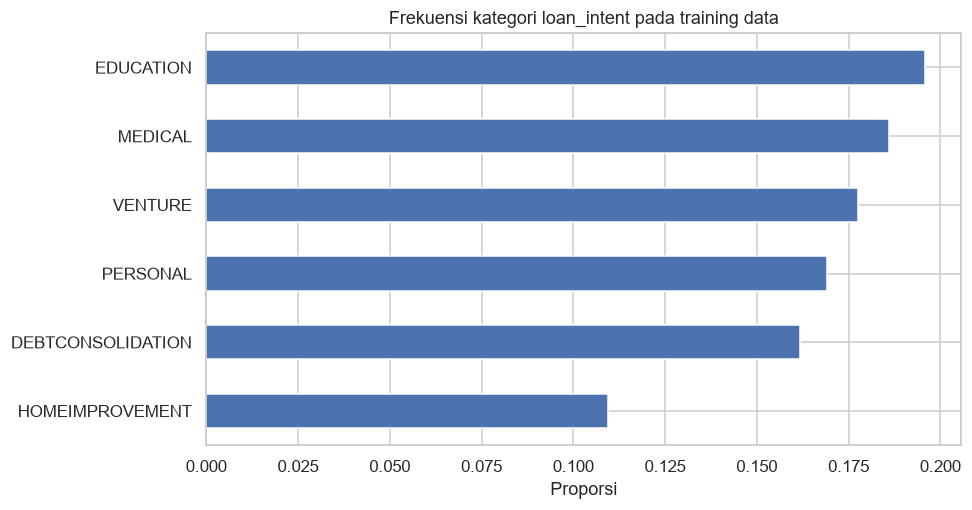

In [28]:
freq_map_demo.sort_values().plot(
    kind="barh",
    figsize=(9, 4.8)
)
plt.title("Frekuensi kategori loan_intent pada training data")
plt.xlabel("Proporsi")
plt.ylabel("")
plt.tight_layout()
plt.show()

<div style="text-align: justify; line-height: 1.65;">Grafik menunjukkan bahwa enam kategori <code>loan_intent</code> memiliki frekuensi yang masih relatif tersebar dan tidak ada satu kategori yang mendominasi secara ekstrem. Cardinality fitur ini juga rendah karena hanya memiliki enam kategori. Kondisi tersebut membuat penambahan kolom melalui One Hot Encoding masih cukup terkendali.</div>


## **11.4 One Hot Encoding untuk Fitur Nominal**


In [29]:
nominal_cols = ["person_home_ownership", "loan_intent"]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

train_ohe = ohe.fit_transform(X_train_prep[nominal_cols])
val_ohe = ohe.transform(X_val_prep[nominal_cols])
test_ohe = ohe.transform(X_test_prep[nominal_cols])

ohe_cols = ohe.get_feature_names_out(nominal_cols)

train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_cols, index=X_train_prep.index)
val_ohe_df = pd.DataFrame(val_ohe, columns=ohe_cols, index=X_val_prep.index)
test_ohe_df = pd.DataFrame(test_ohe, columns=ohe_cols, index=X_test_prep.index)

X_train_encoded = pd.concat([X_train_prep.drop(columns=nominal_cols), train_ohe_df], axis=1)
X_val_encoded = pd.concat([X_val_prep.drop(columns=nominal_cols), val_ohe_df], axis=1)
X_test_encoded = pd.concat([X_test_prep.drop(columns=nominal_cols), test_ohe_df], axis=1)

print("Shape sebelum One Hot Encoding:", X_train_prep.shape)
print("Shape setelah One Hot Encoding:", X_train_encoded.shape)

Shape sebelum One Hot Encoding: (22691, 11)
Shape setelah One Hot Encoding: (22691, 19)


<div style="text-align: justify; line-height: 1.65;">Setelah One Hot Encoding diterapkan pada <code>person_home_ownership</code> dan <code>loan_intent</code>, jumlah fitur meningkat dari <b>11 menjadi 19 kolom</b>. Kenaikan dimensi masih relatif kecil untuk dataset ini. Encoder dipelajari dari training data dan <code>handle_unknown='ignore'</code> menjaga agar kategori yang tidak dikenal pada validation atau test tidak menyebabkan proses transformasi gagal.</div>


## **12. Feature Scaling**


<div style="text-align: justify; line-height: 1.65;">Scaling menyetarakan representasi feature numerik yang memiliki rentang berbeda. StandardScaler, MinMaxScaler, dan RobustScaler diperkenalkan agar peserta dapat melihat bahwa hasil transformasi dapat berbeda walaupun sumber datanya sama.</div>

## **12.1 StandardScaler, MinMaxScaler, dan RobustScaler**


In [30]:
scale_demo = X_train_encoded[["loan_amnt"]]

demo_scalers = {
    "Original": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

scale_comparison = []
for name, scaler_demo in demo_scalers.items():
    if scaler_demo is None:
        values = scale_demo["loan_amnt"].to_numpy()
    else:
        values = scaler_demo.fit_transform(scale_demo).ravel()

    scale_comparison.append({
        "method": name,
        "min": values.min(),
        "max": values.max(),
        "mean": values.mean(),
        "std": values.std()
    })

scale_comparison = pd.DataFrame(scale_comparison)
display(scale_comparison.round(3))

,method,min,max,mean,std
0,Original,500.000,35000.000,9622.966,6302.090
1,StandardScaler,-1.448,4.027,-0.000,1.000
2,MinMaxScaler,0.000,1.000,0.264,0.183
3,RobustScaler,-1.010,3.636,0.219,0.849


<div style="text-align: justify; line-height: 1.65;">Ketiga scaler menghasilkan representasi yang berbeda pada <code>loan_amnt</code>. StandardScaler menghasilkan mean mendekati <b>0</b> dan standard deviation <b>1</b>. MinMaxScaler memetakan data ke rentang <b>0 sampai 1</b>, sedangkan RobustScaler menghasilkan rentang sekitar <b>-1,010 sampai 3,636</b> dengan memanfaatkan median dan IQR. Output ini menunjukkan bahwa scaling tidak mengubah urutan observasi, tetapi mengubah skala numeriknya sesuai karakter metode.</div>


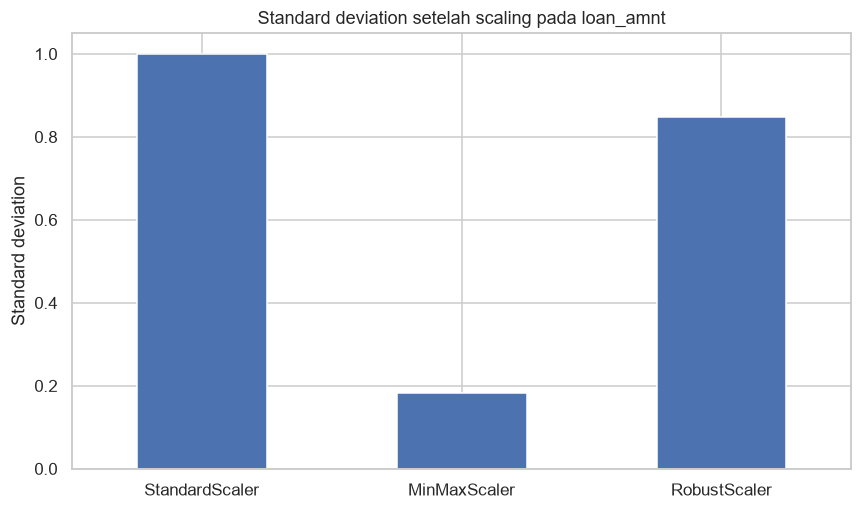

In [31]:
scale_comparison.loc[
    scale_comparison["method"] != "Original",
    ["method", "std"]
].set_index("method").plot(
    kind="bar",
    legend=False,
    figsize=(8, 4.8)
)
plt.title("Standard deviation setelah scaling pada loan_amnt")
plt.ylabel("Standard deviation")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<div style="text-align: justify; line-height: 1.65;">Grafik standard deviation memperlihatkan efek transformasi yang berbeda. StandardScaler memiliki standard deviation tepat sekitar 1 karena metode ini memang menstandardisasi data menggunakan mean dan standard deviation. MinMaxScaler menghasilkan standard deviation yang lebih kecil karena seluruh nilai dipadatkan ke rentang 0 sampai 1, sementara RobustScaler mempertahankan penyebaran berdasarkan median dan IQR. Perbedaan tersebut bukan ukuran metode mana yang selalu lebih baik, tetapi menunjukkan tujuan transformasi yang berbeda.</div>


## **12.2 StandardScaler sebagai Treatment Final**


In [32]:
scale_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

scaler = StandardScaler()

X_train_final = X_train_encoded.copy()
X_val_final = X_val_encoded.copy()
X_test_final = X_test_encoded.copy()

X_train_final[scale_cols] = scaler.fit_transform(X_train_encoded[scale_cols])
X_val_final[scale_cols] = scaler.transform(X_val_encoded[scale_cols])
X_test_final[scale_cols] = scaler.transform(X_test_encoded[scale_cols])

display(X_train_final.head())

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
7126,-0.438949,-0.128601,1.076154,3,-0.892238,1.618217,-0.851517,0,-0.444681,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15645,-0.922814,0.855803,0.064240,1,0.853214,0.153494,-0.007866,0,-0.444681,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7626,-0.600238,0.923515,-0.694696,2,-0.511412,0.719853,-0.945256,1,-0.691489,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
20390,-0.116373,-0.216017,-0.188739,2,-0.765296,1.182055,-0.664039,0,0.295743,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
7969,-0.761526,-0.223246,0.570197,3,-0.733561,1.364332,-0.664039,0,-0.938298,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


<div style="text-align: justify; line-height: 1.65;">Tabel hasil scaling menunjukkan bahwa fitur numerik kontinu sekarang berada dalam skala terstandarisasi dengan nilai positif dan negatif di sekitar pusat distribusi. Pada saat yang sama, <code>loan_grade</code> tetap menggunakan representasi ordinal 0 sampai 6, <code>cb_person_default_on_file</code> tetap 0 atau 1, dan kolom hasil One Hot Encoding tetap berbentuk indikator 0 atau 1. Pemisahan treatment ini menjaga setiap jenis fitur sesuai makna representasinya.</div>


## **13. Final Preprocessing Check**


In [33]:
def final_check(name, X_split):
    print(name)
    print("Shape:", X_split.shape)
    print("Total missing value:", X_split.isna().sum().sum())
    print("Non numeric columns:", X_split.select_dtypes(exclude=np.number).columns.tolist())
    print()

final_check("TRAIN", X_train_final)
final_check("VALIDATION", X_val_final)
final_check("TEST", X_test_final)

print("Kolom train sama dengan validation:", X_train_final.columns.equals(X_val_final.columns))
print("Kolom train sama dengan test:", X_train_final.columns.equals(X_test_final.columns))

TRAIN
Shape: (22691, 19)
Total missing value: 0
Non numeric columns: []

VALIDATION
Shape: (4862, 19)
Total missing value: 0
Non numeric columns: []

TEST
Shape: (4863, 19)
Total missing value: 0
Non numeric columns: []

Kolom train sama dengan validation: True
Kolom train sama dengan test: True


<div style="text-align: justify; line-height: 1.65;">Pemeriksaan akhir menunjukkan training data memiliki shape <b>(22.691, 19)</b>, validation <b>(4.862, 19)</b>, dan test <b>(4.863, 19)</b>. Seluruh subset memiliki <b>0 missing value</b>, tidak memiliki kolom nonnumerik, dan struktur kolom training sama dengan validation maupun test. Kondisi ini menunjukkan bahwa preprocessing sudah menghasilkan tiga subset dengan format yang konsisten dan siap digunakan pada tahap modeling.</div>


## **14. Ringkasan Treatment Final**


<div style="text-align: justify; line-height: 1.65;">
<table style="border-collapse:collapse; width:100%;">
<tr><th style="text-align:left; padding:6px;">Tahap</th><th style="text-align:left; padding:6px;">Treatment</th></tr>
<tr><td style="padding:6px;">Exact duplicate</td><td style="padding:6px;">Menghapus record yang identik</td></tr>
<tr><td style="padding:6px;">Invalid age</td><td style="padding:6px;">Mengubah nilai 123 tahun atau lebih menjadi missing value, kemudian median imputation</td></tr>
<tr><td style="padding:6px;">Invalid employment length</td><td style="padding:6px;">Mengubah nilai yang lebih besar dari usia menjadi missing value, kemudian median imputation</td></tr>
<tr><td style="padding:6px;">Missing value numerik</td><td style="padding:6px;">Median imputation dari training data</td></tr>
<tr><td style="padding:6px;">Statistical outlier</td><td style="padding:6px;">Validasi domain terlebih dahulu, nilai ekstrem yang masih valid tetap dipertahankan</td></tr>
<tr><td style="padding:6px;">Skewness person_income</td><td style="padding:6px;">Log1p transformation</td></tr>
<tr><td style="padding:6px;">Binary categorical</td><td style="padding:6px;">Binary mapping</td></tr>
<tr><td style="padding:6px;">Ordinal categorical</td><td style="padding:6px;">Ordinal mapping</td></tr>
<tr><td style="padding:6px;">Nominal categorical</td><td style="padding:6px;">One Hot Encoding, Frequency Encoding diperkenalkan sebagai alternatif</td></tr>
<tr><td style="padding:6px;">Numerical scaling</td><td style="padding:6px;">StandardScaler</td></tr>
</table>
</div>

<div style="text-align: justify; line-height: 1.65;">Treatment final dipilih karena sesuai dengan karakteristik dataset dan tetap mudah dipahami untuk baseline pembelajaran. Metode lain tetap diperkenalkan sebagai pembanding agar peserta memahami bahwa preprocessing bukan proses yang selalu memiliki satu jawaban untuk semua dataset.</div>

## **15. Mini Assignment**


<div style="text-align: justify; line-height: 1.65;"><b>Feature Selection</b><br>Eksplorasi apakah seluruh feature perlu digunakan atau terdapat feature yang redundant atau kurang informatif.<br><br><b>Class Imbalance Handling</b><br>Eksplorasi class weight, random oversampling, random undersampling, atau SMOTE. Jika menggunakan resampling, treatment hanya dilakukan pada training data agar validation dan test tetap merepresentasikan data asli.</div>